In [3]:
import numpy as np 
import pandas as pd
from src import utils, db
import matplotlib.pyplot as plt
from datetime import datetime
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def datetime64_to_matlab_serial(dates):
    """
    Convert an array of datetime64 values to MATLAB serial date numbers.

    Parameters:
    dates (numpy.ndarray): Array of datetime64 values.

    Returns:
    list: List of MATLAB serial date numbers.
    """
    matlab_reference_date = datetime(1970, 1, 1)  # Unix epoch

    # Convert datetime64 to Python datetime
    python_datetimes = [pd.Timestamp(dt).to_pydatetime() for dt in dates]

    # Calculate the MATLAB serial date number
    matlab_serial_dates = []
    for dt in python_datetimes:
        delta = dt - matlab_reference_date
        matlab_serial_date = 719529 + delta.days + delta.seconds / 86400.0 + delta.microseconds / 86400.0 / 1e6
        matlab_serial_dates.append(matlab_serial_date)

    return np.array(matlab_serial_dates)

def datetime2datenum(dt):
    """ dt: list or array, y:m:d:h:m:s:ms """
    import datetime
    dtime = datetime.datetime(dt[0], dt[1], dt[2], dt[3], dt[4], dt[5], dt[6])
    mdn = dtime + datetime.timedelta(days = 366)
    frac_seconds = (dtime-datetime.datetime(dtime.year,dtime.month,dtime.day,0,0,0)).seconds / (24.0 * 60.0 * 60.0)
    frac_microseconds = dtime.microsecond / (24.0 * 60.0 * 60.0 * 1000000.0)
    return mdn.toordinal() + frac_seconds + frac_microseconds

def get_pupil_df(m1, pupil_path: str = "Z:\data\Miguel\Facevideos"):
    from pathlib import Path
    pupil_path = Path(pupil_path)
    p_path = Path.joinpath(pupil_path, m1.name, m1.datexp, m1.blk, f"{m1.name}_{m1.datexp}_{m1.blk}_pupil.npy")
    pupil = np.load(p_path, allow_pickle=True)
    df = pd.DataFrame(pupil, columns=['Y', 'M', 'D', 'H', 'MM', 'S', 'MS', 'pupil_x', 'pupil_y', 'area'])
    df['time'] = df.apply(lambda x: datetime(x['Y'].astype(int), x['M'].astype(int), x['D'].astype(int), 
                                            x['H'].astype(int), x['MM'].astype(int), x['S'].astype(int), x['MS'].astype(int)), axis=1)
    df.drop(columns=['Y', 'M', 'D', 'H', 'MM', 'S', 'MS'], inplace=True)
    df['serialtime'] = df.apply(lambda x: datetime64_to_matlab_serial(np.array([x['time']]))[0], axis=1)
    return df

def get_frametimes(MouseObject):
    from scipy.interpolate import interp1d
    frames_time = MouseObject._data_var[0]
    ixx = (frames_time[:-1] > 2.5) * (frames_time[1:] < 2.5)
    iframes = np.argwhere(ixx).flatten()
    isamp = np.argwhere(MouseObject._data_var[1] > 1).flatten()
    ts = MouseObject._data_var[1][isamp]
    tframes = interp1d(isamp, ts)(iframes)
    nframes = len(tframes)
    return tframes, nframes

def load_cam_features(m1, camera_path: str = "Z:\data\Miguel\Facevideos"):
    from pathlib import Path
    camera_path = Path(camera_path)
    cam_path = Path.joinpath(camera_path, m1.name, m1.datexp, m1.blk, f"{m1.name}_{m1.datexp}_{m1.blk}_full_proc.npy")
    cam_proc = np.load(cam_path, allow_pickle=True).item()
    return cam_proc

def interp_to_corridor(frameselector, feature: str):
    ntrials = frameselector["trial_no"].astype(int).max()
    interp_feature = np.empty((ntrials, 400))
    for trial_no in frameselector["trial_no"].unique():
        trial_no = int(trial_no)
        trial_feature= frameselector.query(f"trial_no == {trial_no}")[feature].values
        trial_distance = frameselector.query(f"trial_no == {trial_no}")["distance"].values
        if (trial_distance[0] > 0) & (trial_no > 1):
            previous_trial_feature= frameselector.query(f"trial_no == {trial_no-1}")[feature].values[-1]
            #append 0 to the beginning
            trial_distance = np.insert(trial_distance, 0, 0)
            trial_feature = np.insert(trial_feature, 0, previous_trial_feature)
        elif (trial_distance[0] > 0) & (trial_no == 1):
            trial_distance = np.insert(trial_distance, 0, 0)
            trial_feature = np.insert(trial_feature, 0, trial_feature[0])
        trial_distance = np.round(trial_distance, 0).astype(int)
        interp_feature[trial_no-1] = np.interp(np.arange(400), trial_distance, trial_feature)
    return interp_feature

def plot_feature(feature, ylabel: str, labelypos: int = 60, ylabel_offset: int = 0):
    from scipy.stats import sem
    cat_a = feature[:,[0,2],:].mean(1)
    cat_b = feature[:,[1,3],:].mean(1)
    rew_gran_mean = cat_a.mean(axis=0)
    rew_gran_sem = sem(cat_a, axis=0)
    nrew_gran_mean = cat_b.mean(axis=0)
    nrew_gran_sem = sem(cat_b, axis=0)
    fig, ax = plt.subplots(1,2, figsize=(8, 4), sharex=True, sharey=True)
    ax[0].plot(rew_gran_mean[0], color='tab:green')
    ax[0].fill_between(np.arange(400), rew_gran_mean[0]-rew_gran_sem[0], rew_gran_mean[0]+rew_gran_sem[0], alpha=0.3, color='tab:green')
    ax[0].plot(nrew_gran_mean[0], color='tab:red')
    ax[0].fill_between(np.arange(400), nrew_gran_mean[0]-nrew_gran_sem[0], nrew_gran_mean[0]+nrew_gran_sem[0], alpha=0.3, color='tab:red')
    ax[1].plot(rew_gran_mean[1],  color='tab:green')
    ax[1].fill_between(np.arange(400), rew_gran_mean[1]-rew_gran_sem[1], rew_gran_mean[1]+rew_gran_sem[1], alpha=0.3, color='tab:green')
    ax[1].plot(nrew_gran_mean[1], color='tab:red')
    ax[1].fill_between(np.arange(400), nrew_gran_mean[1]-nrew_gran_sem[1], nrew_gran_mean[1]+nrew_gran_sem[1], alpha=0.3, color='tab:red')
    ax[0].set_ylabel(ylabel)
    ax[0].text(10,labelypos + ylabel_offset, "Active reward collection trials", color='tab:green')
    ax[0].text(10,labelypos, "Non rewarded trials with licks", color='tab:red')
    ax[1].text(10,labelypos + ylabel_offset, "Ignored rewarded trials", color='tab:green')
    ax[1].text(10,labelypos, "Correctly ommited non rewarded trials", color='tab:red')
    for i in range(2):
        ax[i].set_xlabel("Position (cm)")
        ax[i].axvline(150, color='k', linestyle='--', alpha=0.5)
        ax[i].axvline(250, color='k', linestyle='--', alpha=0.5)
        ax[i].axvline(300, color='k', linestyle='--', alpha=0.5)

def get_interp_speed(m1):
    #compute speed
    df = utils.get_movement_df(m1)
    ntrials = m1.frameselector["trial_no"].astype(int).max()
    speed_interp = np.empty((ntrials, 400))
    #interp speed to 400 positions
    for trial_no in m1.frameselector["trial_no"].unique():
        trial_no = int(trial_no)
        trial_speed = df.query(f"trial == {trial_no}")["pitch"].values * 10
        trial_distance = df.query(f"trial == {trial_no}")["distance"].values
        speed_interp[trial_no-1] = np.interp(np.arange(400), trial_distance, trial_speed)
    return speed_interp

In [56]:
dbase = db.get_sessions()
sess = dbase.query("mname == 'VG11' and datexp == '2024_10_31' and blk == '2'")
sess

,mname,datexp,blk,session,round_id
2,VG11,2024_10_31,2,last training,1


In [57]:
from scipy.interpolate import interp1d
from pathlib import Path
name = sess['mname'].values[0]
date = sess['datexp'].values[0]
blk = sess['blk'].values[0]
m = utils.load_mouse(name, date, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_10_31\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])


In [58]:
zcurve = np.load("D:/PROC_zstack/VG11/2024_10_31/2/zbest_ups.npy", allow_pickle=True)

In [59]:
m.frameselector["zdrift"] = zcurve[m.frameselector.index]
m.frameselector

,trial_no,trial_type,contrast,speed,distance,reward_delivery,intertrial,time_fromstart,time_within_trial,istim,zdrift
frame,,,,,,,,,,,
39,1.0,non rewarded,0.039989,2.996537,5.998414,NaN,False,0.277337,0.000000,41.0,7.3
40,1.0,non rewarded,0.151129,3.313789,22.669310,NaN,False,0.570978,0.293641,41.0,7.5
41,1.0,non rewarded,0.221667,1.295393,33.250000,NaN,False,0.888890,0.611553,41.0,7.8
42,1.0,non rewarded,0.318635,2.638210,47.795283,NaN,False,1.184534,0.907197,41.0,7.3
43,1.0,non rewarded,0.435764,2.111780,65.364602,NaN,False,1.494711,1.217374,41.0,7.4
...,...,...,...,...,...,...,...,...,...,...,...
13391,254.0,non rewarded test,0.000000,0.120123,364.800000,NaN,True,4208.878046,314.587481,1.0,10.5
13392,254.0,non rewarded test,0.000000,0.852064,378.100000,NaN,True,4209.191592,314.901027,1.0,10.3
13393,254.0,non rewarded test,0.000000,1.198771,379.379811,NaN,True,4209.511778,315.221213,1.0,11.8


In [60]:
interp_z = interp_to_corridor(m.frameselector, 'zdrift')

In [61]:
interp_z.shape

(254, 400)

In [62]:
trial_no = utils.get_trialno_bytype(m.frameselector)
cat_a = np.concatenate((trial_no["rewarded"], trial_no["rewarded test"]))
cat_b = np.concatenate((trial_no["non rewarded"], trial_no["non rewarded test"]))

In [63]:
from scipy.stats import sem
def plot_catvsdrift(behav_cov_catA, behav_cov_catB, ylabel, xlabel, ax, legend=False):
    cat_a = behav_cov_catA
    cat_b = behav_cov_catB
    ax.plot(cat_a.mean(0), color='#0072B2', linestyle='-', label='Category A')
    ax.fill_between(np.arange(400), cat_a.mean(0)-sem(cat_a, axis=0), cat_a.mean(0)+sem(cat_a, axis=0), alpha=0.3, color='#0072B2')
    ax.plot(cat_b.mean(0), color='#D55E00', linestyle='-', label='Category B')
    ax.fill_between(np.arange(400), cat_b.mean(0)-sem(cat_b, axis=0), cat_b.mean(0)+sem(cat_b, axis=0), alpha=0.3, color='#D55E00')
    ax.set_ylabel(ylabel, labelpad=2)
    ax.set_xticks([0, 150, 300, 400], ['0', '150', '300', '400'])    
    if legend:
        ax.legend(bbox_to_anchor=(1.05, .9), frameon=False)
    if xlabel:
        ax.set_xlabel("Position ($cm$)")
    #fill between 0 and 100 with gray
    ymin, ymax = ax.get_ylim()
    ax.fill_between(np.arange(100), ymin, ymax, color='gray', alpha=0.2)
    ax.axvline(150, color='k', linestyle='--', alpha=0.3)
    ax.axvline(300, color='k', linestyle='--', alpha=0.3)

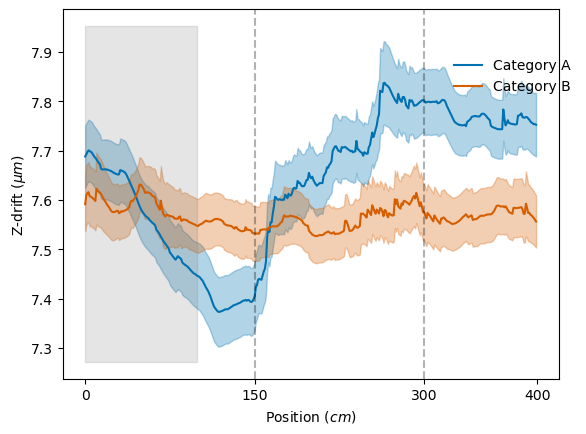

In [64]:
plot_catvsdrift(interp_z[cat_a], interp_z[cat_b], "Z-drift ($\mu m$)", "Position ($cm$)", plt.gca(), legend=True)